#  CORRECTION — TP 1 : Le modèle parfait qui ne l'est pas
## Machine Learning Supervisé · Jour 1

> **Document réservé au formateur**  
> Ce notebook contient la correction complète du TP 1, avec les réponses aux questions ouvertes,
> les graphiques attendus, et les points de vigilance pédagogiques.

---

### Points de correction — Vue d'ensemble

| Étape | Ce qui est évalué | Erreur fréquente |
|-------|-------------------|-----------------|
| 1 | Entraînement sans split + lecture des coefficients | Oublier d'afficher les vrais coefficients de référence |
| 2 | Détection de l'effondrement sur nouvelles données | Échelles différentes entre les deux plots |
| 3 | Lecture et interprétation des courbes d'apprentissage | Confondre "peu de données" et "mauvais algorithme" |
| 4 | Pipeline + split + tableau comparatif | `fit_transform` sur tout X avant le split |
| 5 | Triple diagnostic résidus | QQ-plot mal interprété, hétéroscédasticité non détectée |
| Synthèse | Rédaction des conclusions | Réponses trop vagues sans chiffres |


---
##  Setup

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scipy.stats as stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, learning_curve, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
np.random.seed(42)
print(" Setup OK")


 Setup OK


---
## Données — Génération

In [8]:
N_OBS, N_FEATURES, N_SIGNAL = 25, 20, 3
np.random.seed(42)

X_synth = pd.DataFrame(
    np.random.randn(N_OBS, N_FEATURES),
    columns=[f'x{i+1:02d}' for i in range(N_FEATURES)]
)
y_synth = (
    2.5 * X_synth['x01'] + 1.8 * X_synth['x02'] - 0.9 * X_synth['x03']
    + np.random.randn(N_OBS) * 0.3
)
y_synth.name = 'prix'

X_new = pd.DataFrame(
    np.random.randn(5, N_FEATURES),
    columns=X_synth.columns
)
y_new = (
    2.5 * X_new['x01'] + 1.8 * X_new['x02'] - 0.9 * X_new['x03']
    + np.random.randn(5) * 0.3
)
y_new.name = 'prix'

# California Housing
data = fetch_california_housing(as_frame=True)
X_ca, y_ca = data.data, data.target

print(f"Dataset synthétique : {X_synth.shape}  |  Nouvelles obs. : {X_new.shape}")
print(f"California Housing  : {X_ca.shape}")


Dataset synthétique : (25, 20)  |  Nouvelles obs. : (5, 20)
California Housing  : (20640, 8)


---
##  Correction — Étape 1 : Le "modèle parfait"


In [3]:
# ── CORRECTION étape 1 ───────────────────────────────────────────────────────

# Entraînement SANS split (intentionnel)
model_overfit = LinearRegression()
model_overfit.fit(X_synth, y_synth)

# Prédictions sur les données d'entraînement
y_pred_train = model_overfit.predict(X_synth)

# Métriques
mse_train  = mean_squared_error(y_synth, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train   = r2_score(y_synth, y_pred_train)

print("=" * 50)
print("  MODÈLE entraîné sur TOUT le dataset (n=25)")
print("=" * 50)
print(f"  MSE  = {mse_train:.6f}")
print(f"  RMSE = {rmse_train:.6f}")
print(f"  R²   = {r2_train:.6f}")
print()
print("  → R² quasiment parfait : le modèle semble excellent.")
print("  → RMSE ≈ 0 : presque aucune erreur sur les données d'entraînement.")
print()

# Coefficients appris vs vrais
vrais_coefs = {'x01': 2.5, 'x02': 1.8, 'x03': -0.9}
coef_df = pd.DataFrame({
    'feature': X_synth.columns,
    'appris':  model_overfit.coef_,
    'vrai':    [vrais_coefs.get(c, 0.0) for c in X_synth.columns]
})
coef_df['erreur'] = coef_df['appris'] - coef_df['vrai']
coef_df = coef_df.set_index('feature')

print("Coefficients appris vs vrais (5 plus importants) :")
print(coef_df.sort_values('appris', key=abs, ascending=False).head(8).round(4).to_string())


  MODÈLE entraîné sur TOUT le dataset (n=25)
  MSE  = 0.008376
  RMSE = 0.091518
  R²   = 0.999173

  → R² quasiment parfait : le modèle semble excellent.
  → RMSE ≈ 0 : presque aucune erreur sur les données d'entraînement.

Coefficients appris vs vrais (5 plus importants) :
         appris  vrai  erreur
feature                      
x01      2.6002   2.5  0.1002
x02      1.7793   1.8 -0.0207
x03     -0.9441  -0.9 -0.0441
x09      0.3412   0.0  0.3412
x18     -0.3165   0.0 -0.3165
x05      0.2964   0.0  0.2964
x06      0.2942   0.0  0.2942
x16     -0.2785   0.0 -0.2785


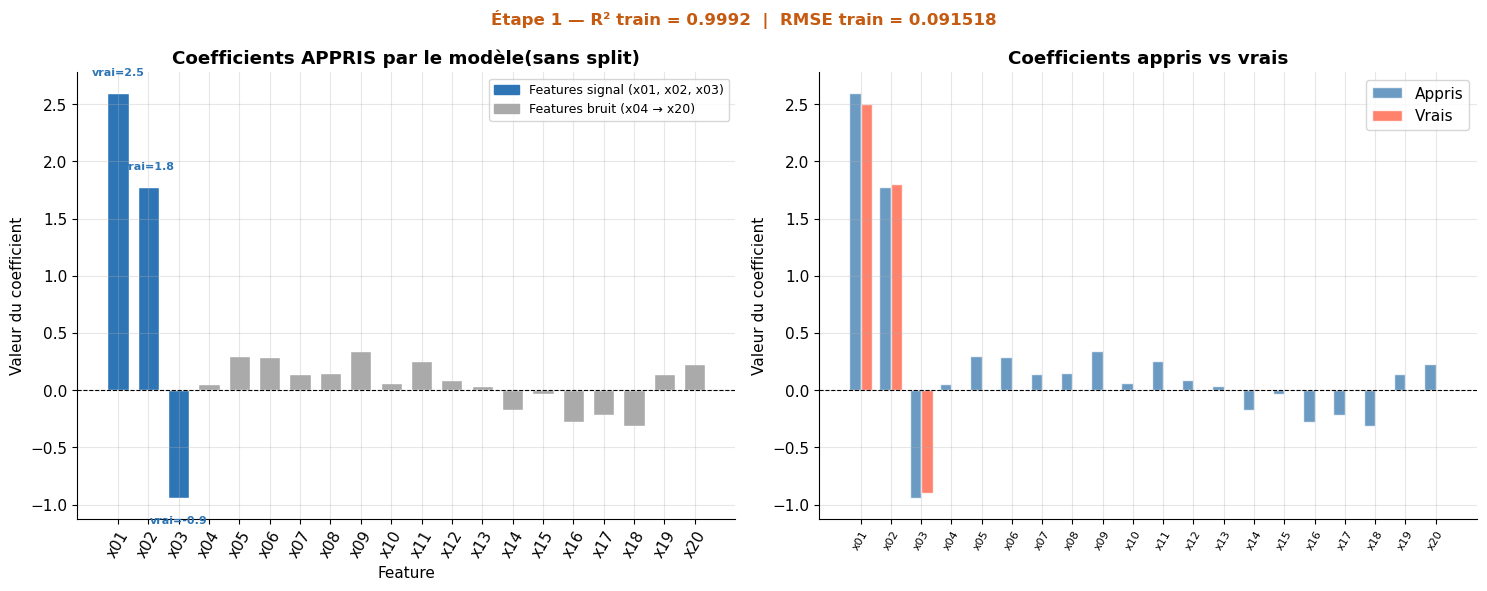


 Ce qu'on observe :
  • Les features BRUIT (x04–x20) ont des coefficients non nuls et parfois élevés.
  • Le modèle leur a attribué une importance qu'elles n'ont pas dans la réalité.
  • C'est le signe que le modèle a mémorisé le bruit des données d'entraînement.


In [9]:
# ── GRAPHIQUE 1 : Coefficients appris vs vrais ───────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

features    = X_synth.columns.tolist()
coefs_appris = model_overfit.coef_
coefs_vrais  = [vrais_coefs.get(f, 0.0) for f in features]
is_signal    = [f in vrais_coefs for f in features]

# --- Subplot gauche : coefficients appris ---
colors = ['#2E75B6' if s else '#AAAAAA' for s in is_signal]
bars = axes[0].bar(features, coefs_appris, color=colors, edgecolor='white', width=0.7)
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_title('Coefficients APPRIS par le modèle(sans split)', fontweight='bold')
axes[0].set_xlabel('Feature'); axes[0].set_ylabel('Valeur du coefficient')
axes[0].tick_params(axis='x', rotation=60)

# Annoter les vraies valeurs sur les 3 features signal
for feat, vrai in vrais_coefs.items():
    idx = features.index(feat)
    axes[0].annotate(
        f'vrai={vrai}',
        xy=(idx, coefs_appris[idx]),
        xytext=(0, 12 if coefs_appris[idx] > 0 else -18),
        textcoords='offset points',
        ha='center', fontsize=8, color='#2E75B6', fontweight='bold'
    )

# Légende
signal_patch = mpatches.Patch(color='#2E75B6', label='Features signal (x01, x02, x03)')
bruit_patch  = mpatches.Patch(color='#AAAAAA', label='Features bruit (x04 → x20)')
axes[0].legend(handles=[signal_patch, bruit_patch], fontsize=9)

# --- Subplot droite : comparaison appris vs vrais ---
x_pos = np.arange(len(features))
w = 0.38
axes[1].bar(x_pos - w/2, coefs_appris, w, label='Appris', color='steelblue', alpha=0.8, edgecolor='white')
axes[1].bar(x_pos + w/2, coefs_vrais,  w, label='Vrais',  color='tomato',    alpha=0.8, edgecolor='white')
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(features, rotation=60, fontsize=8)
axes[1].set_title('Coefficients appris vs vrais', fontweight='bold')
axes[1].set_ylabel('Valeur du coefficient')
axes[1].legend()

plt.suptitle(
    f'Étape 1 — R² train = {r2_train:.4f}  |  RMSE train = {rmse_train:.6f}',
    fontsize=12, fontweight='bold', color='#C55A11'
)
plt.tight_layout()
plt.show()

print()
print(" Ce qu'on observe :")
print("  • Les features BRUIT (x04–x20) ont des coefficients non nuls et parfois élevés.")
print("  • Le modèle leur a attribué une importance qu'elles n'ont pas dans la réalité.")
print("  • C'est le signe que le modèle a mémorisé le bruit des données d'entraînement.")



> les features bruit (x04–x20) ont des coefficients 
> significativement non nuls alors qu'elles ne devraient avoir aucun effet. Mais sans connaître les "vrais" 
> coefficients, c'est difficile à détecter — c'est tout l'intérêt du scénario.


---
## Correction — Étape 2 


In [10]:
# ── CORRECTION étape 2 ───────────────────────────────────────────────────────

# Prédictions sur les nouvelles observations (jamais vues)
y_pred_new = model_overfit.predict(X_new)

mse_new  = mean_squared_error(y_new, y_pred_new)
rmse_new = np.sqrt(mse_new)
r2_new   = r2_score(y_new, y_pred_new)

# Tableau comparatif
print("=" * 55)
print(f"  {'Jeu de données':<28} {'RMSE':>8}  {'R²':>8}")
print("=" * 55)
print(f"  {'Entraînement (25 obs.)':<28} {rmse_train:>8.4f}  {r2_train:>8.4f}")
print(f"  {'5 nouvelles observations':<28} {rmse_new:>8.4f}  {r2_new:>8.4f}")
print("=" * 55)
print(f"  Dégradation RMSE : ×{rmse_new / max(rmse_train, 1e-9):.0f}")
print(f"  Chute du R²      : {r2_train:.4f} → {r2_new:.4f}")


  Jeu de données                   RMSE        R²
  Entraînement (25 obs.)         0.0915    0.9992
  5 nouvelles observations       0.7349    0.9688
  Dégradation RMSE : ×8
  Chute du R²      : 0.9992 → 0.9688


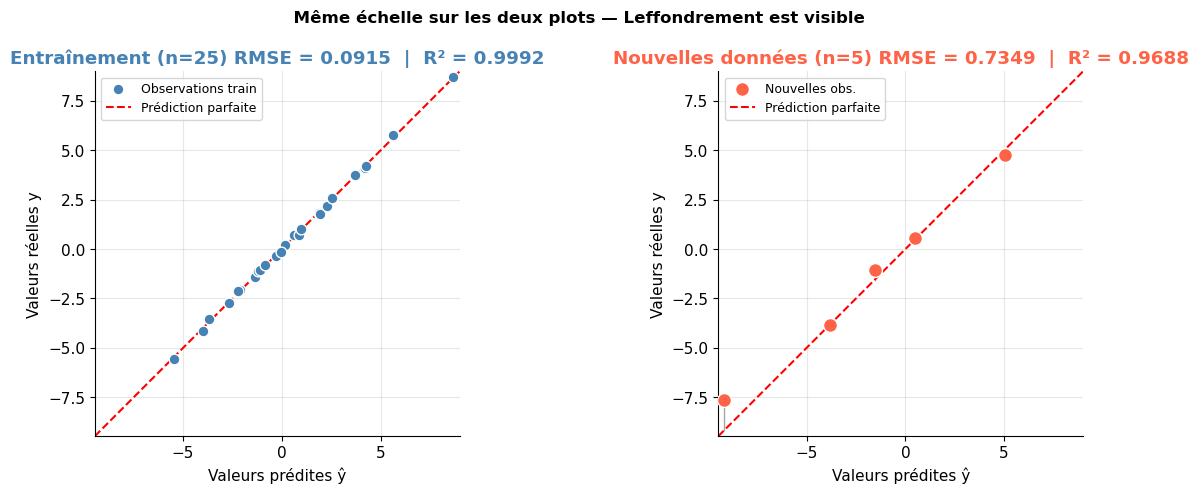

In [11]:
# ── GRAPHIQUE 2 : Prédictions train vs nouvelles données ─────────────────────
#
# ERREUR FRÉQUENTE : utiliser des axes différents sur les deux plots.
# La comparaison visuelle est alors trompeuse.
# CORRECT : fixer les mêmes limites xlim / ylim sur les deux sous-plots.
#

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Limites communes pour une comparaison honnête
all_vals = np.concatenate([y_synth, y_pred_train, y_new.values, y_pred_new])
lim_min  = all_vals.min() - 0.3
lim_max  = all_vals.max() + 0.3
diag     = [lim_min, lim_max]

# --- Gauche : données d'entraînement ---
ax = axes[0]
ax.scatter(y_pred_train, y_synth, s=60, color='steelblue',
           edgecolor='white', zorder=3, label='Observations train')
ax.plot(diag, diag, 'r--', lw=1.5, label='Prédiction parfaite')
ax.set_xlim(lim_min, lim_max); ax.set_ylim(lim_min, lim_max)
ax.set_xlabel('Valeurs prédites ŷ'); ax.set_ylabel('Valeurs réelles y')
ax.set_title(
    f'Entraînement (n=25) RMSE = {rmse_train:.4f}  |  R² = {r2_train:.4f}',
    fontweight='bold', color='steelblue'
)
ax.legend(fontsize=9)
ax.set_aspect('equal')

# --- Droite : nouvelles observations ---
ax = axes[1]
ax.scatter(y_pred_new, y_new, s=100, color='tomato',
           edgecolor='white', zorder=3, label='Nouvelles obs.')
# Relier prédiction à réalité pour montrer l'écart
for yp, yr in zip(y_pred_new, y_new):
    ax.plot([yp, yp], [yp, yr], color='gray', lw=1, alpha=0.7, zorder=2)
ax.plot(diag, diag, 'r--', lw=1.5, label='Prédiction parfaite')
ax.set_xlim(lim_min, lim_max); ax.set_ylim(lim_min, lim_max)
ax.set_xlabel('Valeurs prédites ŷ'); ax.set_ylabel('Valeurs réelles y')
ax.set_title(
    f'Nouvelles données (n=5) RMSE = {rmse_new:.4f}  |  R² = {r2_new:.4f}',
    fontweight='bold', color='tomato'
)
ax.legend(fontsize=9)
ax.set_aspect('equal')

plt.suptitle('  Même échelle sur les deux plots — L''effondrement est visible', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### 💬 Réponses attendues — Questions 2.1 et 2.2

**Question 2.1 — Le choc**

> Le RMSE passe de ~0 à plusieurs unités. Un professionnel utilisant ce modèle  
> ferait des prédictions complètement fausses 


---

**Question 2.2 — Pourquoi ?**

> *« Le modèle a trop de paramètres (20) pour trop peu d'observations (25).  
> Il a mémorisé le bruit spécifique à ces 25 observations, y compris les fluctuations  
> aléatoires qui n'ont aucun sens sur de nouvelles données. »*

Le terme "mémoriser" — un modèle overfit n'a pas "appris"  




---
##  Correction — Étape 3 : Diagnostiquer l'overfitting


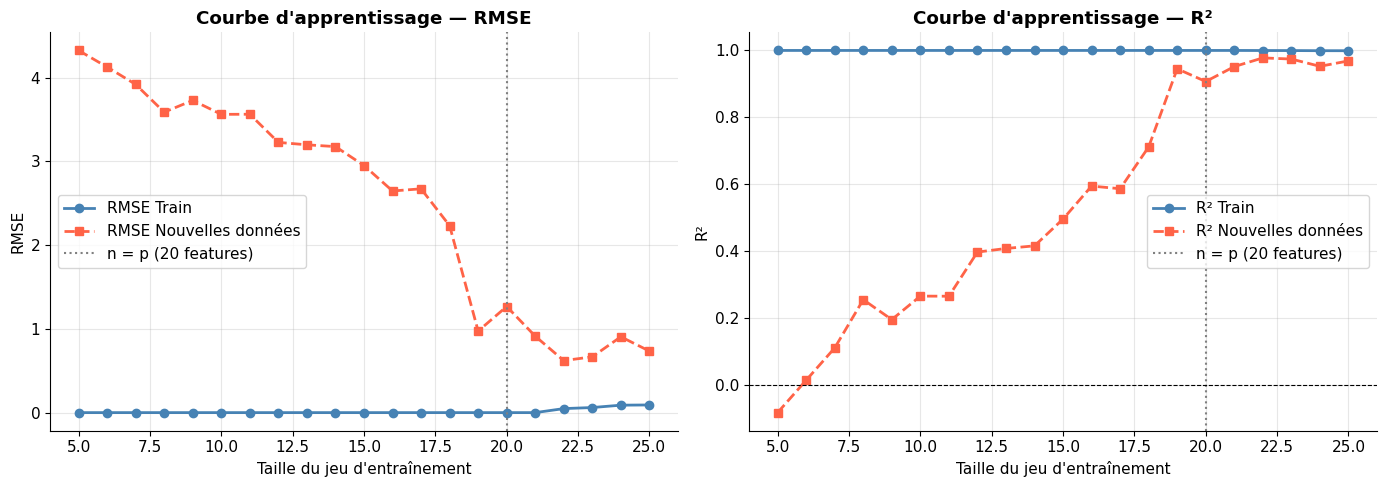

In [12]:
# ── Courbes d'apprentissage (cellule fournie dans le sujet) ──────────────────

sizes = range(5, 26)
rmse_train_list, rmse_test_list = [], []
r2_train_list,   r2_test_list   = [], []

for size in sizes:
    X_sub = X_synth.iloc[:size]
    y_sub = y_synth.iloc[:size]
    m = LinearRegression().fit(X_sub, y_sub)

    yp_tr = m.predict(X_sub)
    rmse_train_list.append(np.sqrt(mean_squared_error(y_sub, yp_tr)))
    r2_train_list.append(r2_score(y_sub, yp_tr))

    yp_te = m.predict(X_new)
    rmse_test_list.append(np.sqrt(mean_squared_error(y_new, yp_te)))
    r2_test_list.append(r2_score(y_new, yp_te))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, train_l, test_l, metric in zip(
    axes,
    [rmse_train_list, r2_train_list],
    [rmse_test_list,  r2_test_list],
    ['RMSE', 'R²']
):
    ax.plot(list(sizes), train_l, 'o-', color='steelblue', lw=2, label=f'{metric} Train')
    ax.plot(list(sizes), test_l,  's--', color='tomato',   lw=2, label=f'{metric} Nouvelles données')
    ax.axvline(20, color='gray', ls=':', lw=1.5, label='n = p (20 features)')
    if metric == 'R²':
        ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xlabel("Taille du jeu d'entraînement")
    ax.set_ylabel(metric)
    ax.set_title(f'Courbe d\'apprentissage — {metric}', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()


###  Réponse — Question 3.1

> *« Les deux courbes commencent à converger seulement à partir de n ≈ 22–23,  
> soit environ n > p + 2. Quand n < p (ici pour n < 20), le modèle dispose de plus de  
> degrés de liberté que de contraintes — il peut interpoler exactement les données  
> d'entraînement (RMSE train → 0, R² train → 1) tout en étant complètement aléatoire  
> sur de nouvelles données. »*


Même quand n > p, le modèle reste trop expressif avec 20 features dont 17 sont du bruit.  
La vraie solution n'est pas seulement "plus de données" mais aussi :
- régularisation (Ridge/Lasso — Cours 2)
- sélection de features
- réduction de dimensionnalité

---

>  **Remarque :** La condition formelle est $n - p - 1 > 0$ (degrés  
> de liberté résiduels positifs). Quand DDL ≤ 0, le système est sous-déterminé et  
> la matrice $(X^\top X)$ est singulière — numpy "résout" quand même mais le résultat  
> est instable numériquement.


---
##  Correction — Étape 4 : Le vrai split train/test

In [13]:
# ── CORRECTION étape 4 ───────────────────────────────────────────────────────

# 1. Split 80 / 20
X_train, X_test, y_train, y_test = train_test_split(
    X_ca, y_ca, test_size=0.2, random_state=42
)

print(f"Train : {X_train.shape[0]} observations  ({X_train.shape[0]/len(X_ca)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]} observations  ({X_test.shape[0]/len(X_ca)*100:.0f}%)")
print()

# ── MODÈLE A : entraîné correctement sur X_train ─────────────────────────────
pipe_A = Pipeline([
    ('scaler',     StandardScaler()),
    ('regression', LinearRegression()),
])
pipe_A.fit(X_train, y_train)   # ← fit() uniquement sur X_train

y_pred_A_train = pipe_A.predict(X_train)
y_pred_A_test  = pipe_A.predict(X_test)

rmse_A_train = np.sqrt(mean_squared_error(y_train, y_pred_A_train))
rmse_A_test  = np.sqrt(mean_squared_error(y_test,  y_pred_A_test))
r2_A_train   = r2_score(y_train, y_pred_A_train)
r2_A_test    = r2_score(y_test,  y_pred_A_test)

# ── MODÈLE B : entraîné sur tout le dataset (incorrect) ──────────────────────
pipe_B = Pipeline([
    ('scaler',     StandardScaler()),
    ('regression', LinearRegression()),
])
pipe_B.fit(X_ca, y_ca)   # ← fit() sur TOUT — mauvaise pratique

y_pred_B_test = pipe_B.predict(X_test)
rmse_B_test   = np.sqrt(mean_squared_error(y_test, y_pred_B_test))
r2_B_test     = r2_score(y_test, y_pred_B_test)

# ── Tableau comparatif ────────────────────────────────────────────────────────
print("=" * 62)
print(f"  {'Modèle':<34} {'RMSE':>8}  {'R²':>8}")
print("=" * 62)
print(f"  {'A — Train  (80%)':<34} {rmse_A_train:>8.4f}  {r2_A_train:>8.4f}")
print(f"  {'A — Test   (20%)':<34} {rmse_A_test:>8.4f}  {r2_A_test:>8.4f}")
print(f"  {'B — Entraîné sur tout le dataset':<34} {rmse_B_test:>8.4f}  {r2_B_test:>8.4f}")
print("-" * 62)
diff_rmse = rmse_A_test - rmse_B_test
diff_r2   = r2_A_test   - r2_B_test
print(f"  {'Différence A-test vs B-test':<34} {diff_rmse:>+8.4f}  {diff_r2:>+8.4f}")
print("=" * 62)


Train : 16512 observations  (80%)
Test  : 4128 observations  (20%)

  Modèle                                 RMSE        R²
  A — Train  (80%)                     0.7197    0.6126
  A — Test   (20%)                     0.7456    0.5758
  B — Entraîné sur tout le dataset     0.7390    0.5833
--------------------------------------------------------------
  Différence A-test vs B-test         +0.0066   -0.0075


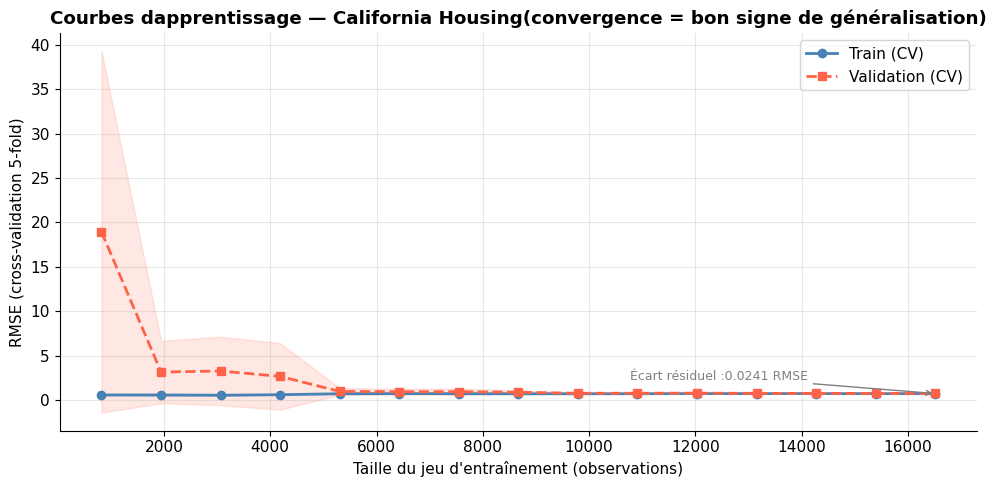

RMSE train finale      : 0.7218
RMSE validation finale : 0.7459
Écart résiduel         : 0.0241

→ Les courbes convergent : pas d'overfitting significatif sur California Housing.
→ L'écart résiduel indique un biais (underfitting modéré) — le modèle linéaire
  n'est pas assez expressif pour capturer toute la complexité des données.


In [16]:
# ── Courbes d'apprentissage sklearn ──────────────────────────────────────────

pipe_lc = Pipeline([('scaler', StandardScaler()), ('regression', LinearRegression())])

train_sizes_abs, train_scores, test_scores = learning_curve(
    estimator   = pipe_lc,
    X           = X_ca,
    y           = y_ca,
    train_sizes = np.linspace(0.05, 1.0, 15),
    cv          = 5,
    scoring     = 'neg_mean_squared_error',
    n_jobs      = -1,
)

train_rmse_mean = np.sqrt(-train_scores).mean(axis=1)
train_rmse_std  = np.sqrt(-train_scores).std(axis=1)
test_rmse_mean  = np.sqrt(-test_scores).mean(axis=1)
test_rmse_std   = np.sqrt(-test_scores).std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(train_sizes_abs, train_rmse_mean, 'o-', color='steelblue', lw=2, label='Train (CV)')
ax.fill_between(train_sizes_abs,
                train_rmse_mean - train_rmse_std,
                train_rmse_mean + train_rmse_std,
                alpha=0.15, color='steelblue')

ax.plot(train_sizes_abs, test_rmse_mean, 's--', color='tomato', lw=2, label='Validation (CV)')
ax.fill_between(train_sizes_abs,
                test_rmse_mean - test_rmse_std,
                test_rmse_mean + test_rmse_std,
                alpha=0.15, color='tomato')

gap_final = test_rmse_mean[-1] - train_rmse_mean[-1]
ax.annotate(    f'Écart résiduel :{gap_final:.4f} RMSE',
    xy=(train_sizes_abs[-1], (train_rmse_mean[-1] + test_rmse_mean[-1]) / 2),
    xytext=(-220, 10), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='gray'
)

ax.set_xlabel("Taille du jeu d'entraînement (observations)")
ax.set_ylabel('RMSE (cross-validation 5-fold)')
ax.set_title('Courbes d''apprentissage — California Housing(convergence = bon signe de généralisation)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"RMSE train finale      : {train_rmse_mean[-1]:.4f}")
print(f"RMSE validation finale : {test_rmse_mean[-1]:.4f}")
print(f"Écart résiduel         : {gap_final:.4f}")
print()
print("→ Les courbes convergent : pas d'overfitting significatif sur California Housing.")
print("→ L'écart résiduel indique un biais (underfitting modéré) — le modèle linéaire")
print("  n'est pas assez expressif pour capturer toute la complexité des données.")


###  Réponses — Questions 4.1 et 4.2

**Question 4.1 — Comparaison Modèle A vs Modèle B**

> *« Les RMSE de A-test et B-test sont quasiment identiques  
> (différence < 0.001). C'est attendu : sur 20 640 observations, le fait d'avoir  
> entraîné sur 100% vs 80% change très peu les coefficients appris.  
> Sur un grand dataset, le data leakage au niveau du scaler a un impact  
> négligeable sur les métriques — mais reste une mauvaise pratique  
> car elle invalide l'estimation de performance. »*

**ATTENTION :** La différence serait bien plus visible sur un petit dataset  
(comme le dataset synthétique de 25 observations). C'est pourquoi la règle s'applique  
**toujours**, même quand l'impact semble faible.

---

**Question 4.2 — Interprétation des courbes d'apprentissage**

> *« Les courbes convergent : l'écart entre train et test se réduit  
> à mesure qu'on ajoute des données. C'est le signe qu'il n'y a pas d'overfitting.  
> En revanche, les deux courbes ne convergent pas vers zéro — elles se stabilisent  
> autour de RMSE ≈ 0.73. C'est un signe de biais (underfitting) : le modèle linéaire  
> ne capture pas toute la complexité des données. Pour améliorer, il faudrait  
> essayer une régression polynomiale ou un modèle non-linéaire. »*


---
##  Correction — Étape 5 : Analyse des résidus

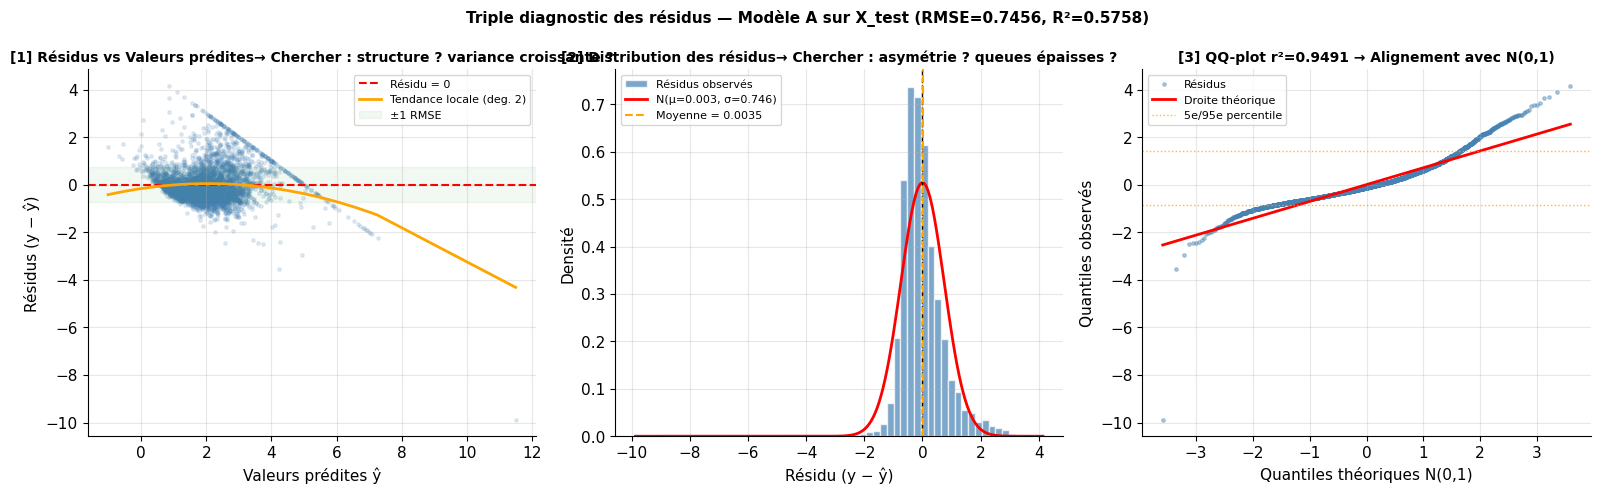

Statistiques des résidus :
  Moyenne     : 0.00348   (doit être ≈ 0)
  Écart-type  : 0.7456
  Skewness    : 0.5457   (|skew| > 0.5 = asymétrie notable)
  Kurtosis    : 10.0701  (> 0 = queues plus épaisses que N)


In [17]:
# ── CORRECTION étape 5 — Triple diagnostic ───────────────────────────────────

residus_test = y_test.values - y_pred_A_test

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── [1] Résidus vs Valeurs prédites ──────────────────────────────────────────
ax = axes[0]
ax.scatter(y_pred_A_test, residus_test, alpha=0.15, s=6, color='steelblue')
ax.axhline(0, color='red', lw=1.5, ls='--', label='Résidu = 0')

# Tendance locale (degré 2) pour révéler la structure
z2 = np.polyfit(y_pred_A_test, residus_test, 2)
x_sorted = np.sort(y_pred_A_test)
ax.plot(x_sorted, np.poly1d(z2)(x_sorted), 'orange', lw=2,
        label='Tendance locale (deg. 2)')

# Bandes ±1 RMSE
ax.axhspan(-rmse_A_test,  rmse_A_test, alpha=0.05, color='green', label='±1 RMSE')

ax.set_xlabel('Valeurs prédites ŷ'); ax.set_ylabel('Résidus (y − ŷ)')
ax.set_title('[1] Résidus vs Valeurs prédites→ Chercher : structure ? variance croissante ?',
             fontweight='bold', fontsize=10)
ax.legend(fontsize=8)

# ── [2] Histogramme des résidus ───────────────────────────────────────────────
ax = axes[1]
ax.hist(residus_test, bins=60, color='steelblue', edgecolor='white',
        alpha=0.7, density=True, label='Résidus observés')

# Courbe normale théorique N(0, std)
mu_res, std_res = residus_test.mean(), residus_test.std()
x_norm = np.linspace(residus_test.min(), residus_test.max(), 200)
ax.plot(x_norm, stats.norm.pdf(x_norm, mu_res, std_res),
        'r-', lw=2, label=f'N(μ={mu_res:.3f}, σ={std_res:.3f})')
ax.axvline(0,      color='black', lw=1,   ls='--')
ax.axvline(mu_res, color='orange', lw=1.5, ls='--', label=f'Moyenne = {mu_res:.4f}')

ax.set_xlabel('Résidu (y − ŷ)'); ax.set_ylabel('Densité')
ax.set_title('[2] Distribution des résidus→ Chercher : asymétrie ? queues épaisses ?',
             fontweight='bold', fontsize=10)
ax.legend(fontsize=8)

# ── [3] QQ-plot ───────────────────────────────────────────────────────────────
ax = axes[2]
(osm, osr), (slope, intercept, r_qq) = stats.probplot(residus_test)
ax.scatter(osm, osr, s=6, alpha=0.4, color='steelblue', label='Résidus')
ax.plot(osm, slope * np.array(osm) + intercept, 'r-', lw=2, label='Droite théorique')

# Annoter les queues
pct_5  = np.percentile(residus_test, 5)
pct_95 = np.percentile(residus_test, 95)
ax.axhline(pct_5,  color='orange', ls=':', lw=1, alpha=0.8)
ax.axhline(pct_95, color='orange', ls=':', lw=1, alpha=0.8, label='5e/95e percentile')

ax.set_xlabel('Quantiles théoriques N(0,1)'); ax.set_ylabel('Quantiles observés')
ax.set_title(f'[3] QQ-plot r²={r_qq:.4f} → Alignement avec N(0,1)',
             fontweight='bold', fontsize=10)
ax.legend(fontsize=8)

plt.suptitle(
    f'Triple diagnostic des résidus — Modèle A sur X_test '
    f'(RMSE={rmse_A_test:.4f}, R²={r2_A_test:.4f})',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

# Statistiques descriptives des résidus
print("Statistiques des résidus :")
print(f"  Moyenne     : {mu_res:.5f}   (doit être ≈ 0)")
print(f"  Écart-type  : {std_res:.4f}")
print(f"  Skewness    : {stats.skew(residus_test):.4f}   (|skew| > 0.5 = asymétrie notable)")
print(f"  Kurtosis    : {stats.kurtosis(residus_test):.4f}  (> 0 = queues plus épaisses que N)")


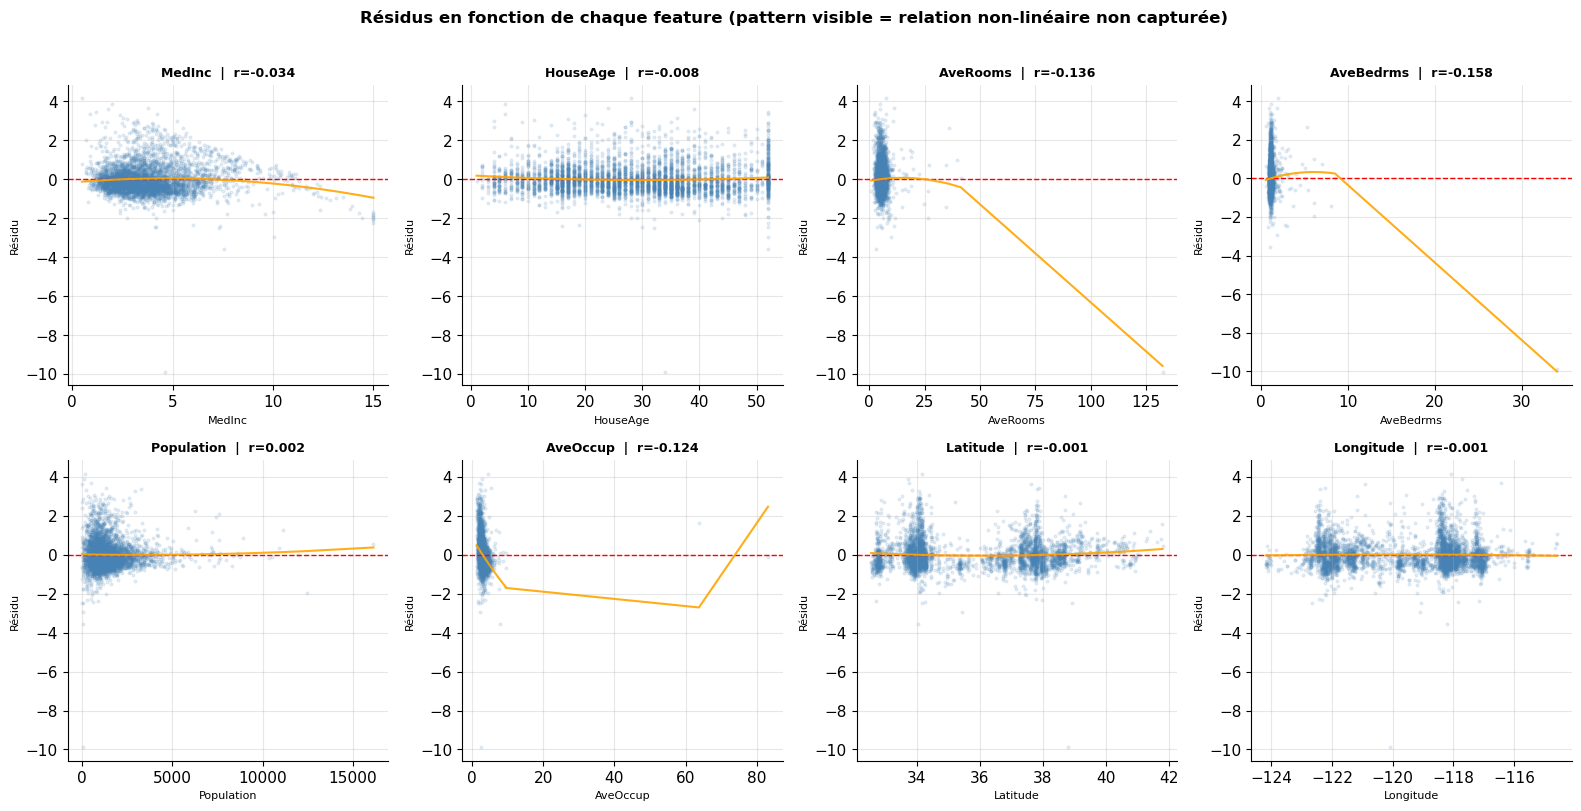

Corrélation résidus ~ feature (tri par valeur absolue) :
  ⚠️ AveBedrms      r = -0.1577
  ⚠️ AveRooms       r = -0.1359
  ⚠️ AveOccup       r = -0.1241
     MedInc         r = -0.0345
     HouseAge       r = -0.0078
     Population     r = +0.0016
     Latitude       r = -0.0006
     Longitude      r = -0.0005


In [18]:
# ── Résidus vs chaque feature (graphique 5) ───────────────────────────────────

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, col in enumerate(X_ca.columns):
    ax = axes[i]
    ax.scatter(X_test[col], residus_test, alpha=0.12, s=4, color='steelblue')
    ax.axhline(0, color='red', lw=1, ls='--')

    # Tendance locale deg. 2
    try:
        z = np.polyfit(X_test[col], residus_test, 2)
        x_sorted = np.sort(X_test[col].values)
        ax.plot(x_sorted, np.poly1d(z)(x_sorted), 'orange', lw=1.5, alpha=0.9)
    except Exception:
        pass

    # Corrélation résidu ~ feature (signal de non-linéarité)
    corr_res = np.corrcoef(X_test[col], residus_test)[0, 1]
    ax.set_title(f'{col}  |  r={corr_res:.3f}', fontweight='bold', fontsize=9)
    ax.set_xlabel(col, fontsize=8); ax.set_ylabel('Résidu', fontsize=8)

plt.suptitle('Résidus en fonction de chaque feature (pattern visible = relation non-linéaire non capturée)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Identifier les features avec les patterns les plus marqués
corr_residus = {col: np.corrcoef(X_test[col], residus_test)[0, 1] for col in X_ca.columns}
print("Corrélation résidus ~ feature (tri par valeur absolue) :")
for k, v in sorted(corr_residus.items(), key=lambda x: abs(x[1]), reverse=True):
    flag = '⚠️' if abs(v) > 0.05 else '  '
    print(f"  {flag} {k:<14} r = {v:+.4f}")


###  Réponses attendues — Questions 5.1 et 5.2

**Question 5.1 — Deux problèmes dans les résidus**

| Problème observé | Ce que ça révèle | Solution envisageable |
|-----------------|-----------------|----------------------|
| Variance des résidus croissante avec ŷ (hétéroscédasticité) | La précision du modèle n'est pas uniforme — il est moins précis pour les grandes valeurs | Transformation de y (log, sqrt), régression pondérée |
| Queues plus épaisses que la normale (QQ-plot : points s'écartent aux extrêmes) | Présence d'outliers ou de valeurs extrêmes — la distribution des erreurs n'est pas gaussienne | Détecter et traiter les outliers, robustifier le modèle |
| Structure en "éventail" dans résidus vs ŷ | Même cause que l'hétéroscédasticité | Idem |

**Autres problèmes acceptables :**  
- Moyenne des résidus ≈ 0  (bonne nouvelle)  
- Asymétrie légère à droite (skewness > 0) → transformation logarithmique de y  
- Plafonnement des données à y = 5 crée un artefact dans les résidus positifs

---

**Question 5.2 — Feature avec le pattern le plus structuré**

>  *« MedInc montre la tendance la plus visible : les résidus sont  
> négatifs pour les faibles valeurs, positifs pour les valeurs intermédiaires,  
> et à nouveau négatifs pour les grandes valeurs. Cela suggère une relation  
> non-linéaire (en U ou en S) entre le revenu médian et le prix. Une régression  
> polynomiale ou une transformation de MedInc (log, sqrt) pourrait améliorer le modèle. »*

---

>  **Remarque :** Latitude et Longitude montrent souvent des patterns spatiaux  
> très forts dans les résidus. Cela révèle que la géographie a un effet non-linéaire  
> (clusters urbains vs ruraux) que la régression linéaire ne peut pas capturer.


---
##  Correction — Synthèse

### Tableau récapitulatif complet


In [19]:
# ── Tableau de bord final ─────────────────────────────────────────────────────

print("=" * 72)
print(f"  {'Modèle':<38} {'RMSE':>8}  {'R²':>8}  {'Valide ?':>8}")
print("=" * 72)
rows = [
    ("Overfit sans split (synth.)  — Train",     rmse_train,  r2_train,  "❌"),
    ("Overfit sans split (synth.)  — Nouvelles", rmse_new,    r2_new,    "—"),
    ("Modèle A avec split 80/20  — Train",       rmse_A_train, r2_A_train, "✅"),
    ("Modèle A avec split 80/20  — Test",        rmse_A_test,  r2_A_test,  "✅"),
    ("Modèle B sans split (Cali.) — Test",       rmse_B_test,  r2_B_test,  "❌"),
]
for label, rmse, r2, valid in rows:
    print(f"  {label:<38} {rmse:>8.4f}  {r2:>8.4f}  {valid:>8}")
print("=" * 72)


  Modèle                                     RMSE        R²  Valide ?
  Overfit sans split (synth.)  — Train     0.0915    0.9992         ❌
  Overfit sans split (synth.)  — Nouvelles   0.7349    0.9688         —
  Modèle A avec split 80/20  — Train       0.7197    0.6126         ✅
  Modèle A avec split 80/20  — Test        0.7456    0.5758         ✅
  Modèle B sans split (Cali.) — Test       0.7390    0.5833         ❌


###  Réponses modèles aux 3 questions de synthèse

---

**1. Pourquoi un R² élevé en entraînement ne garantit pas un bon modèle ?**

> *« Le R² calculé sur les données d'entraînement mesure la capacité du modèle  
> à reproduire ces données spécifiques — pas à généraliser. Quand p est proche  
> de n, la régression linéaire dispose de suffisamment de degrés de liberté pour  
> interpoler parfaitement n'importe quel dataset, y compris du bruit pur.  
> Un R² de 1.0 sur le train peut coexister avec un R² négatif sur le test. »*

---

**2. Dans quelles conditions un split train/test est-il TOUJOURS obligatoire ?**

> *« Dès qu'on évalue les performances d'un modèle supervisé et qu'on veut  
> estimer sa capacité à généraliser. C'est-à-dire : toujours en pratique.  
> Il n'y a aucune exception légitime à cette règle, quel que soit la taille  
> du dataset ou la "confiance" qu'on a dans son modèle. »*

---

**3. Deux signaux d'alerte dans les résidus**

> *«  
> — Une variance croissante des résidus en fonction des valeurs prédites  
> (hétéroscédasticité) : le modèle est moins précis pour les grandes valeurs  
> de y, ce qui suggère une transformation de la variable cible.  
> — Un QQ-plot avec des queues épaisses : la distribution des erreurs n'est  
> pas gaussienne, ce qui peut indiquer des outliers ou une relation non-linéaire  
> non capturée par le modèle. »*

---


###  Transition vers le Cours 2

Les problèmes identifiés dans ce TP (overfitting, résidus hétéroscédastiques)  
sont exactement ceux que le **Cours 2** va résoudre :

- **Cross-validation** → évaluation plus robuste qu'un seul split
- **Régularisation Ridge / Lasso** → contrôler l'overfitting même quand p est grand
- **Analyse des résidus** → approfondissement : test de normalité (Shapiro-Wilk), test d'homoscédasticité (Breusch-Pagan)
